# Analytic Task 4 – Crosses per 90 Analysis

## Analytic Question

Do forwards and midfielders differ significantly in their average number of crosses per 90 minutes during the FIFA World Cup 2026?

Forwards and midfielders have different roles in attack play. Generally, forwards are more near the opponent’s goal, midfielders are more involved in pushing the ball forward and creating attacking chances at various points on the field. The aim of this study is to find out if there is a statistically significant difference in the average number of crosses per 90 minutes of forwards and midfielders in the FIFA World Cup 2026.

## Data Source

The data used for this analysis is sourced from the FBref FIFA World Cup 2026 Player Miscellaneous Statistics, one of the approved data sources listed in the project brief.

The main variables required for this analysis are:

- **Player** – player name
- **Pos** – player's position
- **90s** – playing time measured in 90-minute units
- **Crs** – total number of crosses made
Only players that played in the tournament will be considered. For the comparison of positions, only players labeled as forwards (FW) and midfielders (MF) are used.

Total crosses per 90 minutes will be computed by dividing each player's total crosses by their playing time. The data was initially downloaded from FBref as an Excel file (.xls) and will first be converted to CSV using Python. The next step would be data wrangling, cleaning, sampling, descriptive statistics, confidence interval estimation, hypothesis testing and visualizations.

In [2]:
import pandas as pd

# Import the original FBref dataset
tables = pd.read_html("Player Miscellaneous.xls")

# Use the first table
df = tables[0]

print("Dataset imported successfully.")
print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

Dataset imported successfully.
Dataset shape: (499, 20)

First 5 rows:


Unnamed: 0_level_0  Unnamed: 1_level_0 Unnamed: 2_level_0  \
                  Rk              Player                Pos   
0                  1    Brenden Aaronson                 MF   
1                  2      Thelo Aasgaard                 MF   
2                  3    Hamza Abdelkarim                 FW   
3                  4  Hossam Abdelmaguid                 DF   
4                  5  Mohamed Abdelmonem                 DF   

  Unnamed: 3_level_0 Unnamed: 4_level_0 Unnamed: 5_level_0 Unnamed: 6_level_0  \
               Squad                Age               Born                90s   
0             us USA                 25               2000                0.8   
1          no Norway                 24               2002                1.0   
2           eg Egypt                 18               2008                0.7   
3           eg Egypt                 25               2001                0.7   
4           eg Egypt                 27               1999                0.2   

  Performance                                                     \
         CrdY CrdR 2CrdY Fls Fld Off Crs Int TklW PKwon PKcon OG   
0           0    0     0   2   1   0   1   0    1   NaN   NaN  0   
1           0    0     0   0   3   0   0   3    1   NaN   NaN  0   
2           0    0     0   2   0   0   0   0    0   NaN   NaN  0   
3           0    0     0   1   0   0   0   1    0   NaN   NaN  0   
4           0    0     0   1   0   0   0   0    0   NaN   NaN  0   

  Unnamed: 19_level_0  
              Matches  
0             Matches  
1             Matches  
2             Matches  
3             Matches  
4             Matches

In [3]:
# Flatten FBref multi-level column headings first
df.columns = [col[1] if isinstance(col, tuple) else col for col in df.columns]

print("Column names:")
print(df.columns.tolist())

# Save as raw CSV
raw_file = "task4_crosses_raw.csv"

df.to_csv(raw_file, index=False)

print("\nRaw CSV created successfully!")
print("File name:", raw_file)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Column names:
['Rk', 'Player', 'Pos', 'Squad', 'Age', 'Born', '90s', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Off', 'Crs', 'Int', 'TklW', 'PKwon', 'PKcon', 'OG', 'Matches']

Raw CSV created successfully!
File name: task4_crosses_raw.csv
Rows: 499
Columns: 20


In [4]:

raw_df = pd.read_csv("task4_crosses_raw.csv")

print("DATA INSPECTION")
print("--------------------------------------------")

print("Dataset shape:")
print(raw_df.shape)

print("\nColumn names:")
print(raw_df.columns.tolist())

print("\nFirst 5 rows:")
display(raw_df.head())

print("\nMissing values:")
print(raw_df.isnull().sum())

print("\nData types:")
print(raw_df.dtypes)

DATA INSPECTION
--------------------------------------------
Dataset shape:
(499, 20)

Column names:
['Rk', 'Player', 'Pos', 'Squad', 'Age', 'Born', '90s', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Off', 'Crs', 'Int', 'TklW', 'PKwon', 'PKcon', 'OG', 'Matches']

First 5 rows:


,Rk,Player,Pos,Squad,Age,Born,90s,CrdY,CrdR,2CrdY,Fls,Fld,Off,Crs,Int,TklW,PKwon,PKcon,OG,Matches
0,1,Brenden Aaronson,MF,us USA,25,2000,0.8,0,0,0,2,1,0,1,0,1,NaN,NaN,0,Matches
1,2,Thelo Aasgaard,MF,no Norway,24,2002,1.0,0,0,0,0,3,0,0,3,1,NaN,NaN,0,Matches
2,3,Hamza Abdelkarim,FW,eg Egypt,18,2008,0.7,0,0,0,2,0,0,0,0,0,NaN,NaN,0,Matches
3,4,Hossam Abdelmaguid,DF,eg Egypt,25,2001,0.7,0,0,0,1,0,0,0,1,0,NaN,NaN,0,Matches
4,5,Mohamed Abdelmonem,DF,eg Egypt,27,1999,0.2,0,0,0,1,0,0,0,0,0,NaN,NaN,0,Matches



Missing values:
Rk           0
Player       0
Pos          0
Squad        0
Age          0
Born         0
90s          0
CrdY         0
CrdR         0
2CrdY        0
Fls          0
Fld          0
Off          0
Crs          0
Int          0
TklW         0
PKwon      499
PKcon      499
OG           0
Matches      0
dtype: int64

Data types:
Rk           int64
Player      object
Pos         object
Squad       object
Age          int64
Born         int64
90s        float64
CrdY         int64
CrdR         int64
2CrdY        int64
Fls          int64
Fld          int64
Off          int64
Crs          int64
Int          int64
TklW         int64
PKwon      float64
PKcon      float64
OG           int64
Matches     object
dtype: object


In [5]:

crosses_df = df[['Player', 'Pos', '90s', 'Crs']].copy()

print("SELECTED VARIABLES")
print("--------------------------------------------")
print("Dataset shape:", crosses_df.shape)

print("\nFirst 10 rows:")
display(crosses_df.head(10))

print("\nPosition counts:")
print(crosses_df['Pos'].value_counts())

print("\nMissing values:")
print(crosses_df.isnull().sum())

SELECTED VARIABLES
--------------------------------------------
Dataset shape: (499, 4)

First 10 rows:


,Player,Pos,90s,Crs
0,Brenden Aaronson,MF,0.8,1
1,Thelo Aasgaard,MF,1.0,0
2,Hamza Abdelkarim,FW,0.7,0
3,Hossam Abdelmaguid,DF,0.7,0
4,Mohamed Abdelmonem,DF,0.2,0
5,Ali Abdi,DF,3.0,4
6,Saud Abdulhamid,DF,3.0,5
7,Abdulla Abdullaev,DF,2.0,0
8,Yusuf Abdurisag,FW,1.1,0
9,Husam Abu Dahab,DF,2.0,0



Position counts:
Pos
MF       163
DF       150
FW        82
FW,MF     38
GK        26
MF,FW     16
DF,MF     15
MF,DF      7
DF,FW      2
Name: count, dtype: int64

Missing values:
Player    0
Pos       0
90s       0
Crs       0
dtype: int64


In [6]:


clean_crosses = crosses_df.copy()


clean_crosses = clean_crosses[
    clean_crosses['Pos'].isin(['FW', 'MF'])
].copy()

clean_crosses = clean_crosses[
    clean_crosses['90s'] > 0
].copy()


clean_crosses = clean_crosses.drop_duplicates(
    subset=['Player', 'Pos']
)


clean_crosses = clean_crosses.reset_index(drop=True)

print("DATA CLEANING RESULTS")
print("--------------------------------------------")

print("Cleaned dataset shape:")
print(clean_crosses.shape)

print("\nPlayers by position:")
print(clean_crosses['Pos'].value_counts())

print("\nMissing values:")
print(clean_crosses.isnull().sum())

print("\nMinimum playing time (90s):")
print(clean_crosses['90s'].min())

print("\nDuplicate records:")
print(clean_crosses.duplicated(subset=['Player', 'Pos']).sum())

print("\nFirst 10 cleaned rows:")
display(clean_crosses.head(10))

DATA CLEANING RESULTS
--------------------------------------------
Cleaned dataset shape:
(235, 4)

Players by position:
Pos
MF    156
FW     79
Name: count, dtype: int64

Missing values:
Player    0
Pos       0
90s       0
Crs       0
dtype: int64

Minimum playing time (90s):
0.1

Duplicate records:
0

First 10 cleaned rows:


,Player,Pos,90s,Crs
0,Brenden Aaronson,MF,0.8,1
1,Thelo Aasgaard,MF,1.0,0
2,Hamza Abdelkarim,FW,0.7,0
3,Yusuf Abdurisag,FW,1.1,0
4,ChÃ© Adams,FW,1.6,0
5,Jayden Adams,MF,1.3,0
6,Tyler Adams,MF,3.8,0
7,Ali Ahmed,MF,2.6,13
8,Yunus AkgÃ¼n,MF,1.0,2
9,Maghnes Akliouche,MF,0.1,1


In [7]:
# Calculate crosses per 90 minutes

clean_crosses['Crosses_per_90'] = (
    clean_crosses['Crs'] / clean_crosses['90s']
)

print("CROSSES PER 90 CALCULATION")
print("--------------------------------------------")

print("First 10 rows:")
display(
    clean_crosses[
        ['Player', 'Pos', '90s', 'Crs', 'Crosses_per_90']
    ].head(10)
)

print("\nCrosses per 90 summary:")
print(clean_crosses['Crosses_per_90'].describe())

print("\nMissing values in Crosses_per_90:")
print(clean_crosses['Crosses_per_90'].isnull().sum())

CROSSES PER 90 CALCULATION
--------------------------------------------
First 10 rows:


,Player,Pos,90s,Crs,Crosses_per_90
0,Brenden Aaronson,MF,0.8,1,1.25
1,Thelo Aasgaard,MF,1.0,0,0.00
2,Hamza Abdelkarim,FW,0.7,0,0.00
3,Yusuf Abdurisag,FW,1.1,0,0.00
4,ChÃ© Adams,FW,1.6,0,0.00
5,Jayden Adams,MF,1.3,0,0.00
6,Tyler Adams,MF,3.8,0,0.00
7,Ali Ahmed,MF,2.6,13,5.00
8,Yunus AkgÃ¼n,MF,1.0,2,2.00
9,Maghnes Akliouche,MF,0.1,1,10.00



Crosses per 90 summary:
count    235.000000
mean       1.599358
std        2.399159
min        0.000000
25%        0.000000
50%        0.697674
75%        2.282197
max       20.000000
Name: Crosses_per_90, dtype: float64

Missing values in Crosses_per_90:
0


In [8]:

cleaned_file = "task4_crosses_cleaned.csv"

clean_crosses.to_csv(
    cleaned_file,
    index=False,
    encoding="utf-8-sig"
)

print("CLEANED CSV SAVED")
print("--------------------------------------------")
print("File name:", cleaned_file)
print("Rows:", clean_crosses.shape[0])
print("Columns:", clean_crosses.shape[1])

print("\nVariables included:")
print(clean_crosses.columns.tolist())

CLEANED CSV SAVED
--------------------------------------------
File name: task4_crosses_cleaned.csv
Rows: 235
Columns: 5

Variables included:
['Player', 'Pos', '90s', 'Crs', 'Crosses_per_90']


In [9]:

fw_population = clean_crosses[
    clean_crosses['Pos'] == 'FW'
].copy()

mf_population = clean_crosses[
    clean_crosses['Pos'] == 'MF'
].copy()

print("POPULATION AND SAMPLING APPROACH")
print("--------------------------------------------")

print("Target Population:")
print("FIFA World Cup 2026 players classified exclusively as FW or MF")
print("who recorded playing time greater than 0.")

print("\nPopulation size:")
print("Forwards (FW):", len(fw_population))
print("Midfielders (MF):", len(mf_population))
print("Total:", len(fw_population) + len(mf_population))

print("\nSampling Method:")
print("Stratified random sampling by player position (FW and MF).")
print("An equal number of players will be randomly selected from each group.")
print("A fixed random seed will be used to make the sample reproducible.")

POPULATION AND SAMPLING APPROACH
--------------------------------------------
Target Population:
FIFA World Cup 2026 players classified exclusively as FW or MF
who recorded playing time greater than 0.

Population size:
Forwards (FW): 79
Midfielders (MF): 156
Total: 235

Sampling Method:
Stratified random sampling by player position (FW and MF).
An equal number of players will be randomly selected from each group.
A fixed random seed will be used to make the sample reproducible.


In [10]:

sample_size_per_group = 50
random_seed = 42

fw_sample = fw_population.sample(
    n=sample_size_per_group,
    random_state=random_seed
)

mf_sample = mf_population.sample(
    n=sample_size_per_group,
    random_state=random_seed
)

# Combine both groups
sample_df = pd.concat(
    [fw_sample, mf_sample],
    ignore_index=True
)

print("STRATIFIED RANDOM SAMPLE")
print("--------------------------------------------")

print("Sampling method: Stratified random sampling")
print("Random seed:", random_seed)

print("\nSample size by position:")
print(sample_df['Pos'].value_counts())

print("\nTotal sample size:")
print(len(sample_df))

print("\nFirst 10 sampled players:")
display(
    sample_df[
        ['Player', 'Pos', '90s', 'Crs', 'Crosses_per_90']
    ].head(10)
)

STRATIFIED RANDOM SAMPLE
--------------------------------------------
Sampling method: Stratified random sampling
Random seed: 42

Sample size by position:
Pos
FW    50
MF    50
Name: count, dtype: int64

Total sample size:
100

First 10 sampled players:


,Player,Pos,90s,Crs,Crosses_per_90
0,MojmÃ­r Chytil,FW,0.1,0,0.000000
1,Hamza Abdelkarim,FW,0.7,0,0.000000
2,Brian Brobbey,FW,2.5,1,0.400000
3,Jhon CÃ³rdoba,FW,1.1,0,0.000000
4,Gilson Benchimol,FW,0.9,0,0.000000
5,Firas Chaouat,FW,0.5,0,0.000000
6,Ãlex Arce,FW,0.6,0,0.000000
7,Nicolas Jackson,FW,2.6,1,0.384615
8,Ahmed Alaaeldin,FW,0.5,0,0.000000
9,Gabriel Ãvalos,FW,1.6,0,0.000000


In [11]:


sample_file = "task4_crosses_sample.csv"

sample_df.to_csv(
    sample_file,
    index=False,
    encoding="utf-8-sig"
)

print("SAMPLE CSV SAVED")
print("--------------------------------------------")
print("File name:", sample_file)
print("Total rows:", len(sample_df))
print("Forwards:", (sample_df['Pos'] == 'FW').sum())
print("Midfielders:", (sample_df['Pos'] == 'MF').sum())

print("\nColumns included:")
print(sample_df.columns.tolist())

SAMPLE CSV SAVED
--------------------------------------------
File name: task4_crosses_sample.csv
Total rows: 100
Forwards: 50
Midfielders: 50

Columns included:
['Player', 'Pos', '90s', 'Crs', 'Crosses_per_90']


In [12]:


descriptive_stats = sample_df.groupby('Pos')['Crosses_per_90'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Std_Dev='std',
    Variance='var',
    Minimum='min',
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75),
    Maximum='max'
)

# Round values for clearer presentation
descriptive_stats = descriptive_stats.round(2)

print("DESCRIPTIVE STATISTICS — CROSSES PER 90")
print("--------------------------------------------")

display(descriptive_stats)

DESCRIPTIVE STATISTICS — CROSSES PER 90
--------------------------------------------


,Count,Mean,Median,Std_Dev,Variance,Minimum,Q1,Q3,Maximum
Pos,,,,,,,,,
FW,50,0.54,0.00,1.27,1.62,0.0,0.00,0.40,6.33
MF,50,2.66,1.46,3.49,12.17,0.0,0.09,4.12,20.00


In [13]:


summary_file = "task4_crosses_summary.csv"

descriptive_stats.to_csv(
    summary_file,
    encoding="utf-8-sig"
)

print("SUMMARY CSV SAVED")
print("--------------------------------------------")
print("File name:", summary_file)

print("\nDescriptive statistics saved:")
display(descriptive_stats)

SUMMARY CSV SAVED
--------------------------------------------
File name: task4_crosses_summary.csv

Descriptive statistics saved:


,Count,Mean,Median,Std_Dev,Variance,Minimum,Q1,Q3,Maximum
Pos,,,,,,,,,
FW,50,0.54,0.00,1.27,1.62,0.0,0.00,0.40,6.33
MF,50,2.66,1.46,3.49,12.17,0.0,0.09,4.12,20.00


In [14]:
from scipy import stats
import numpy as np


fw_data = sample_df[sample_df['Pos'] == 'FW']['Crosses_per_90']
mf_data = sample_df[sample_df['Pos'] == 'MF']['Crosses_per_90']

def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = data.mean()
    std = data.std(ddof=1)
    se = std / np.sqrt(n)
    
    t_critical = stats.t.ppf(
        (1 + confidence) / 2,
        df=n - 1
    )
    
    margin_error = t_critical * se
    
    lower = mean - margin_error
    upper = mean + margin_error
    
    return mean, se, lower, upper


fw_mean, fw_se, fw_lower, fw_upper = confidence_interval(fw_data)
mf_mean, mf_se, mf_lower, mf_upper = confidence_interval(mf_data)

print("95% CONFIDENCE INTERVALS FOR CROSSES PER 90")
print("--------------------------------------------")

print("\nForwards (FW)")
print(f"Mean: {fw_mean:.2f}")
print(f"Standard Error: {fw_se:.3f}")
print(f"95% CI: ({fw_lower:.2f}, {fw_upper:.2f})")

print("\nMidfielders (MF)")
print(f"Mean: {mf_mean:.2f}")
print(f"Standard Error: {mf_se:.3f}")
print(f"95% CI: ({mf_lower:.2f}, {mf_upper:.2f})")

95% CONFIDENCE INTERVALS FOR CROSSES PER 90
--------------------------------------------

Forwards (FW)
Mean: 0.54
Standard Error: 0.180
95% CI: (0.18, 0.90)

Midfielders (MF)
Mean: 2.66
Standard Error: 0.493
95% CI: (1.66, 3.65)


In [15]:


alpha = 0.05

print("HYPOTHESES")
print("--------------------------------------------")

print("H0: μFW = μMF")
print("There is no statistically significant difference in the mean")
print("crosses per 90 minutes between forwards and midfielders.")

print("\nH1: μFW ≠ μMF")
print("There is a statistically significant difference in the mean")
print("crosses per 90 minutes between forwards and midfielders.")

print(f"\nSignificance Level (alpha): {alpha}")

HYPOTHESES
--------------------------------------------
H0: μFW = μMF
There is no statistically significant difference in the mean
crosses per 90 minutes between forwards and midfielders.

H1: μFW ≠ μMF
There is a statistically significant difference in the mean
crosses per 90 minutes between forwards and midfielders.

Significance Level (alpha): 0.05


In [16]:


print("ASSUMPTION CHECK")
print("--------------------------------------------")


print("Sample Sizes:")
print("Forwards:", len(fw_data))
print("Midfielders:", len(mf_data))


print("\nMissing Values:")
print("Forwards:", fw_data.isnull().sum())
print("Midfielders:", mf_data.isnull().sum())


fw_skew = fw_data.skew()
mf_skew = mf_data.skew()

print("\nSkewness:")
print(f"Forwards: {fw_skew:.2f}")
print(f"Midfielders: {mf_skew:.2f}")


fw_variance = fw_data.var()
mf_variance = mf_data.var()

print("\nSample Variances:")
print(f"Forwards: {fw_variance:.2f}")
print(f"Midfielders: {mf_variance:.2f}")


print("\nIndependence:")
print("The forward and midfielder samples contain different players,")
print("so the two groups are treated as independent.")


print("\nTest Selection:")
print("Welch's independent two-sample t-test will be used.")
print("This test does not require equal population variances.")

ASSUMPTION CHECK
--------------------------------------------
Sample Sizes:
Forwards: 50
Midfielders: 50

Missing Values:
Forwards: 0
Midfielders: 0

Skewness:
Forwards: 3.23
Midfielders: 2.83

Sample Variances:
Forwards: 1.62
Midfielders: 12.17

Independence:
The forward and midfielder samples contain different players,
so the two groups are treated as independent.

Test Selection:
Welch's independent two-sample t-test will be used.
This test does not require equal population variances.


In [17]:
from scipy.stats import ttest_ind


t_stat, p_value = ttest_ind(
    fw_data,
    mf_data,
    equal_var=False
)

alpha = 0.05
mean_difference = fw_data.mean() - mf_data.mean()

print("WELCH'S TWO-SAMPLE T-TEST")
print("--------------------------------------------")

print(f"Forward Mean: {fw_data.mean():.2f}")
print(f"Midfielder Mean: {mf_data.mean():.2f}")
print(f"Mean Difference (FW - MF): {mean_difference:.2f}")

print(f"\nt-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")
print(f"Significance Level (alpha): {alpha}")

print("\nHypotheses:")
print("H0: Mean crosses per 90 for FW = Mean crosses per 90 for MF")
print("H1: Mean crosses per 90 for FW ≠ Mean crosses per 90 for MF")

if p_value < alpha:
    print("\nDecision: Reject H0")
    print("Conclusion: There is sufficient evidence of a statistically significant")
    print("difference in mean crosses per 90 between forwards and midfielders.")
else:
    print("\nDecision: Fail to reject H0")
    print("Conclusion: There is insufficient evidence of a statistically significant")
    print("difference in mean crosses per 90 between forwards and midfielders.")

WELCH'S TWO-SAMPLE T-TEST
--------------------------------------------
Forward Mean: 0.54
Midfielder Mean: 2.66
Mean Difference (FW - MF): -2.11

t-statistic: -4.026
p-value: 0.0002
Significance Level (alpha): 0.05

Hypotheses:
H0: Mean crosses per 90 for FW = Mean crosses per 90 for MF
H1: Mean crosses per 90 for FW ≠ Mean crosses per 90 for MF

Decision: Reject H0
Conclusion: There is sufficient evidence of a statistically significant
difference in mean crosses per 90 between forwards and midfielders.


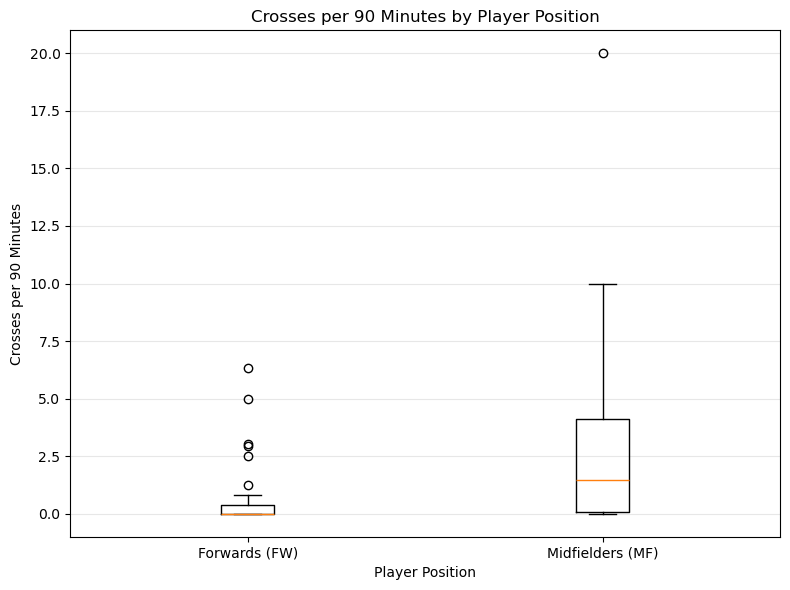

Boxplot saved successfully as task4_crosses_boxplot.png


In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.boxplot(
    [fw_data, mf_data],
    tick_labels=['Forwards (FW)', 'Midfielders (MF)']
)

plt.title('Crosses per 90 Minutes by Player Position')
plt.xlabel('Player Position')
plt.ylabel('Crosses per 90 Minutes')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    "task4_crosses_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Boxplot saved successfully as task4_crosses_boxplot.png")

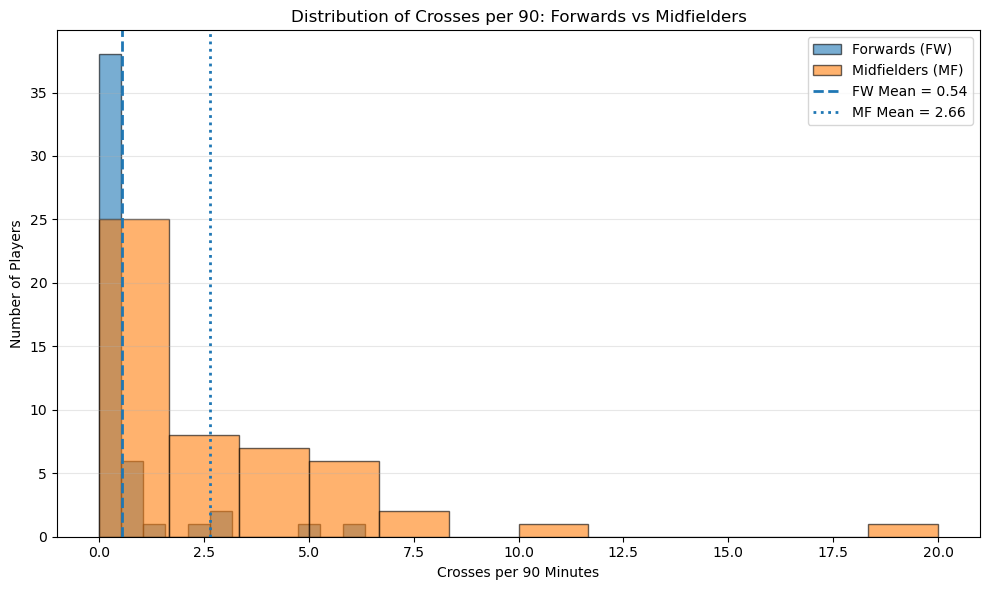

Histogram saved successfully as task4_crosses_histogram.png


In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot distributions
plt.hist(
    fw_data,
    bins=12,
    alpha=0.6,
    label='Forwards (FW)',
    edgecolor='black'
)

plt.hist(
    mf_data,
    bins=12,
    alpha=0.6,
    label='Midfielders (MF)',
    edgecolor='black'
)

# Add mean reference lines
plt.axvline(
    fw_data.mean(),
    linestyle='--',
    linewidth=2,
    label=f'FW Mean = {fw_data.mean():.2f}'
)

plt.axvline(
    mf_data.mean(),
    linestyle=':',
    linewidth=2,
    label=f'MF Mean = {mf_data.mean():.2f}'
)

plt.title('Distribution of Crosses per 90: Forwards vs Midfielders')
plt.xlabel('Crosses per 90 Minutes')
plt.ylabel('Number of Players')

plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Save visualisation
plt.savefig(
    "task4_crosses_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Histogram saved successfully as task4_crosses_histogram.png")

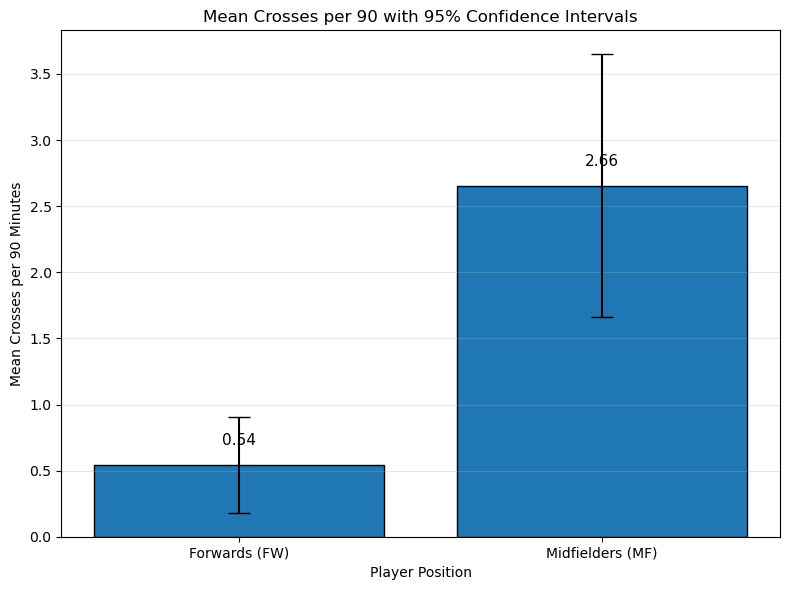

Mean comparison chart saved successfully as task4_crosses_mean_ci.png


In [20]:


positions = ['Forwards (FW)', 'Midfielders (MF)']
means = [fw_mean, mf_mean]


errors = [
    fw_mean - fw_lower,
    mf_mean - mf_lower
]

plt.figure(figsize=(8, 6))

bars = plt.bar(
    positions,
    means,
    yerr=errors,
    capsize=8,
    edgecolor='black'
)


for bar, mean in zip(bars, means):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        f'{mean:.2f}',
        ha='center',
        fontsize=11
    )

plt.title('Mean Crosses per 90 with 95% Confidence Intervals')
plt.xlabel('Player Position')
plt.ylabel('Mean Crosses per 90 Minutes')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    "task4_crosses_mean_ci.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Mean comparison chart saved successfully as task4_crosses_mean_ci.png")

## Results, Interpretation and Conclusion

A stratified random sample was taken of 100 FIFA World Cup 2026 players, 50 forwards (FW) and 50 midfielders (MF). Crosses were corrected for playing time, and crosses per 90 min were calculated.
The descriptive statistics showed that forwards averaged 0.54 crosses per 90 minutes, compared to a much higher 2.66 for midfielders. Forwards had a standard deviation of 1.27 and midfielders had a standard deviation of 3.49 , suggesting more variance with midfielders .
The 95% confidence interval for mean crosses per 90 was 0.18 to 0.90 for forwards and 1.66 to 3.65 for midfielders.

Welch’s independent two-sample t-test was conducted to determine whether the difference between two groups was statistically significant at the significance level of α = 0.05. The test produced a t-statistic of -4.026 and p-value of 0.0002. The p-value was 0.0002, which is less than 0.05, so the null hypothesis was rejected.. Thus, there is strong statistical evidence that the mean number of crosses per 90 minutes between forwards and midfielders in the sampled FIFA World Cup 2026 players is different. Sample results show that midfielders average more crosses per 90 minutes than forwards.

The visualizations support the statistical results. The mean comparison chart shows that the mean of the midfielders is higher. The boxplot and histogram show the difference in the distributions and the presence of the relatively high values. The skewness scores for for ward and midfielders were 3.23 and 2.83, respectively, both positively skewed.

### Conclusion

There was a statistically significant difference in the mean number of crosses per 90 minutes between forwards and midfielders. Forwards averaged 0.54 crosses per 90 compared to 2.66 for midfielders, which gives a sample mean difference of approximately -2.11 crosses per 90 (FW - MF). Welch’s two sample t-test, p = 0.0002, was sufficiently strong evidence to reject the null hypothesis at the 5% significance level. In this sample, therefore, midfielders completed a significantly higher average number of crosses per 90 minutes than forwards.

### Limitations
There are several limitations to this analysis. Only players with a position classification of FW or MF were included, thus combined position classifications were excluded. The analysis was based on a stratified random sample of 50 players per position rather than all eligible players. Crosses per 90 can also be unstable for players with very little playing time. The cleaned dataset had players with as little as 0.1 of a 90 minute period; which can lead to per-90 values that are unusually high. This is evident from the positively skewed distributions and high maximum values of Therefore, findings should be interpreted in light of variation in individual playing time and the existence of extreme per-90 data points.